In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'C:\\Users\\Nyachomo\\OneDrive\\Desktop\\datascience'

In [4]:
df=pd.read_excel('datasets/students_eligible_for_industrial_attachment.xlsx')

In [6]:
#PLACEMENT BY YEAR (BARCHART)
placement_by_year=(df.groupby(['attachment_start_year','placement_status'])).size().reset_index(name='student_count')
placement_by_year

,attachment_start_year,placement_status,student_count
0,2023,NOT PLACED,775
1,2023,PLACED,2135
2,2024,NOT PLACED,529
3,2024,PLACED,3367
4,2025,NOT PLACED,813
5,2025,PLACED,4741
6,2026,NOT PLACED,764
7,2026,PLACED,2074


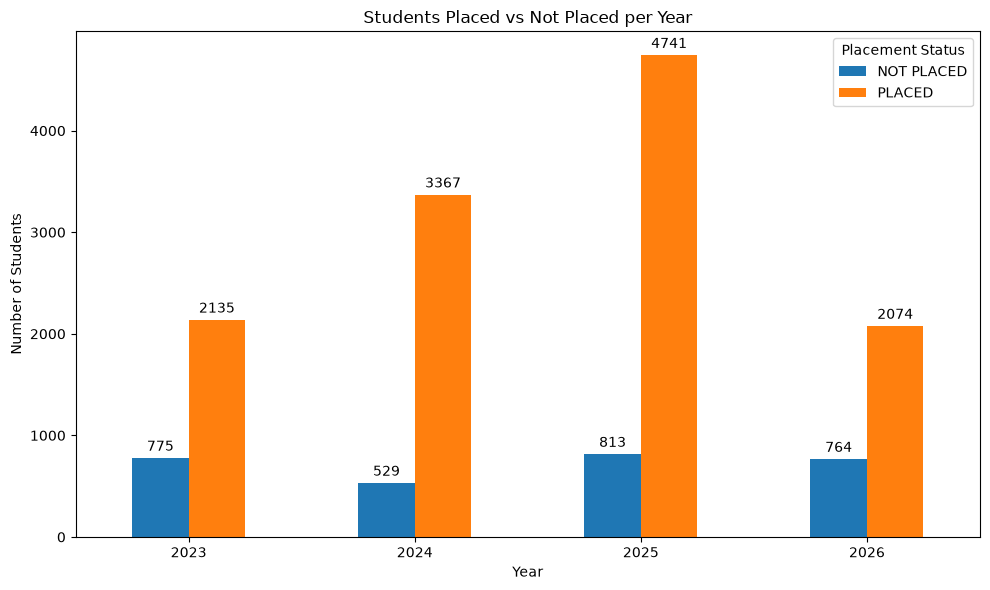

In [8]:

chart_data = (
    df.groupby(
        ['attachment_start_year', 'placement_status']
    )
    .size()
    .unstack(fill_value=0)
)

ax = chart_data.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Year')
plt.ylabel('Number of Students')
plt.title('Students Placed vs Not Placed per Year')

plt.xticks(rotation=0)

plt.legend(title='Placement Status')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

YEARLY PLACEMENT SUMMARY


placement_status,NOT PLACED,PLACED,TOTAL,PLACEMENT_RATE
attachment_start_year,,,,
2023,775,2135,2910,73.367698
2024,529,3367,3896,86.421971
2025,813,4741,5554,85.361901
2026,764,2074,2838,73.079634


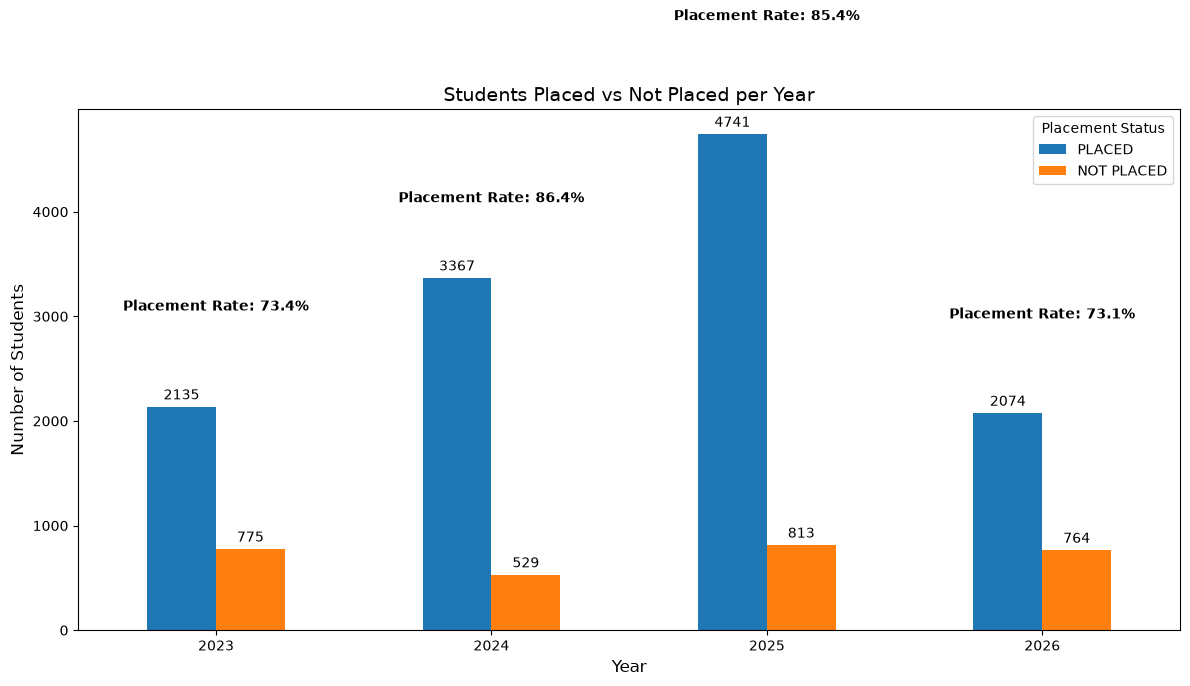

In [9]:

# ============================================================
# 1. GROUP STUDENTS BY YEAR AND PLACEMENT STATUS
# ============================================================

year_summary = (
    df.groupby(
        ['attachment_start_year', 'placement_status']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 2. MAKE SURE PLACED AND NOT PLACED COLUMNS EXIST
# ============================================================

if 'PLACED' not in year_summary.columns:
    year_summary['PLACED'] = 0

if 'NOT PLACED' not in year_summary.columns:
    year_summary['NOT PLACED'] = 0


# ============================================================
# 3. SORT YEARS
# ============================================================

year_summary = year_summary.sort_index()


# ============================================================
# 4. CALCULATE TOTAL STUDENTS PER YEAR
# ============================================================

year_summary['TOTAL'] = (
    year_summary['PLACED'] +
    year_summary['NOT PLACED']
)


# ============================================================
# 5. CALCULATE PLACEMENT RATE
# ============================================================

year_summary['PLACEMENT_RATE'] = (
    year_summary['PLACED'] /
    year_summary['TOTAL']
) * 100


# ============================================================
# 6. DISPLAY THE SUMMARY TABLE
# ============================================================

print("YEARLY PLACEMENT SUMMARY")

display(year_summary)


# ============================================================
# 7. PREPARE DATA FOR THE BAR CHART
# ============================================================

chart_data = year_summary[
    ['PLACED', 'NOT PLACED']
]


# ============================================================
# 8. CREATE BAR CHART
# ============================================================

ax = chart_data.plot(
    kind='bar',
    figsize=(12, 7)
)


# ============================================================
# 9. LABEL THE X AND Y AXES
# ============================================================

plt.xlabel(
    'Year',
    fontsize=12
)

plt.ylabel(
    'Number of Students',
    fontsize=12
)

plt.title(
    'Students Placed vs Not Placed per Year',
    fontsize=14
)


# ============================================================
# 10. KEEP YEAR LABELS HORIZONTAL
# ============================================================

plt.xticks(
    rotation=0
)


# ============================================================
# 11. ADD LEGEND
# ============================================================

plt.legend(
    title='Placement Status'
)


# ============================================================
# 12. ADD STUDENT COUNTS ON TOP OF EACH BAR
# ============================================================

for container in ax.containers:

    ax.bar_label(
        container,
        fmt='%d',
        padding=3
    )


# ============================================================
# 13. ADD PLACEMENT RATE ABOVE EACH YEAR
# ============================================================

for i, rate in enumerate(
    year_summary['PLACEMENT_RATE']
):

    total = year_summary['TOTAL'].iloc[i]

    ax.text(
        i,
        total + (total * 0.05),
        f'Placement Rate: {rate:.1f}%',
        ha='center',
        fontweight='bold'
    )


# ============================================================
# 14. ADJUST CHART LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 15. DISPLAY THE CHART
# ============================================================

plt.show()

YEARLY PLACEMENT AND GRADING TREND


,attachment_start_year,placement_rate,average_score
0,2023,73.367698,89.103448
1,2024,86.421971,92.280654
2,2025,85.361901,93.866069
3,2026,73.079634,92.735117


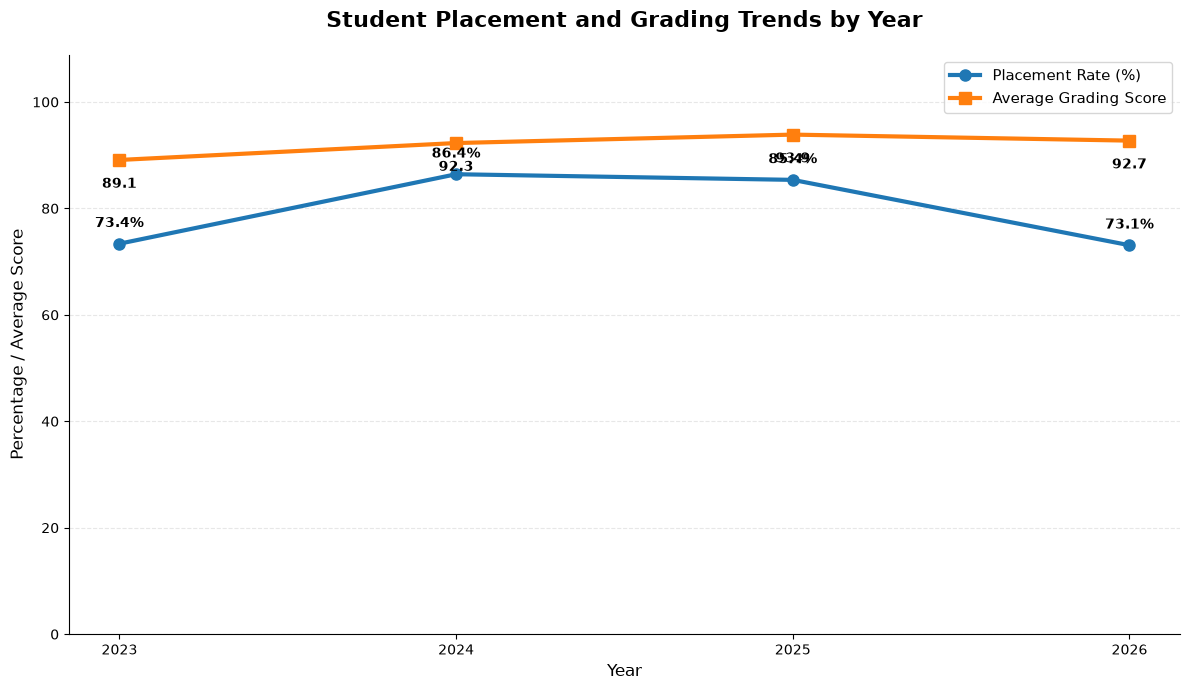

In [10]:
#PLACEMENT TREND VS GRADING 
# ============================================================
# 1. PREPARE YEARLY PLACEMENT DATA
# ============================================================

placement_data = (
    df.groupby('attachment_start_year')
      .agg(
          total_students=('student_name', 'size'),
          placed_students=('placement_status',
                           lambda x: (x == 'PLACED').sum())
      )
      .reset_index()
)


# ============================================================
# 2. CALCULATE PLACEMENT RATE
# ============================================================

placement_data['placement_rate'] = (
    placement_data['placed_students'] /
    placement_data['total_students']
) * 100


# ============================================================
# 3. PREPARE YEARLY GRADING DATA
# ============================================================

grading_data = (
    df.groupby('attachment_start_year')
      .agg(
          average_score=('student_final_score', 'mean')
      )
      .reset_index()
)


# ============================================================
# 4. MERGE PLACEMENT AND GRADING DATA
# ============================================================

trend_data = pd.merge(
    placement_data[
        [
            'attachment_start_year',
            'placement_rate'
        ]
    ],
    grading_data[
        [
            'attachment_start_year',
            'average_score'
        ]
    ],
    on='attachment_start_year',
    how='outer'
)


# ============================================================
# 5. SORT BY YEAR
# ============================================================

trend_data = trend_data.sort_values(
    'attachment_start_year'
)


# ============================================================
# 6. DISPLAY THE DATA USED FOR THE GRAPH
# ============================================================

print("YEARLY PLACEMENT AND GRADING TREND")

display(trend_data)


# ============================================================
# 7. CREATE THE LINE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)


# ============================================================
# 8. PLOT PLACEMENT TREND
# ============================================================

ax.plot(
    trend_data['attachment_start_year'],
    trend_data['placement_rate'],
    marker='o',
    linewidth=3,
    markersize=8,
    label='Placement Rate (%)'
)


# ============================================================
# 9. PLOT GRADING TREND
# ============================================================

ax.plot(
    trend_data['attachment_start_year'],
    trend_data['average_score'],
    marker='s',
    linewidth=3,
    markersize=8,
    label='Average Grading Score'
)


# ============================================================
# 10. ADD VALUES TO PLACEMENT LINE
# ============================================================

for x, y in zip(
    trend_data['attachment_start_year'],
    trend_data['placement_rate']
):

    if pd.notna(y):

        ax.annotate(
            f'{y:.1f}%',
            (x, y),
            xytext=(0, 12),
            textcoords='offset points',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )


# ============================================================
# 11. ADD VALUES TO GRADING LINE
# ============================================================

for x, y in zip(
    trend_data['attachment_start_year'],
    trend_data['average_score']
):

    if pd.notna(y):

        ax.annotate(
            f'{y:.1f}',
            (x, y),
            xytext=(0, -20),
            textcoords='offset points',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )


# ============================================================
# 12. CHART TITLE
# ============================================================

ax.set_title(
    'Student Placement and Grading Trends by Year',
    fontsize=16,
    fontweight='bold',
    pad=20
)


# ============================================================
# 13. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Year',
    fontsize=12
)

ax.set_ylabel(
    'Percentage / Average Score',
    fontsize=12
)


# ============================================================
# 14. FORMAT X-AXIS
# ============================================================

ax.set_xticks(
    trend_data['attachment_start_year']
)


# ============================================================
# 15. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 16. ADD LEGEND
# ============================================================

ax.legend(
    loc='best',
    fontsize=11
)


# ============================================================
# 17. ADJUST Y-AXIS
# ============================================================

ax.set_ylim(
    0,
    max(
        trend_data[
            [
                'placement_rate',
                'average_score'
            ]
        ].max()
    ) + 15
)


# ============================================================
# 18. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 19. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 20. DISPLAY GRAPH
# ============================================================

plt.show()

PLACEMENT TREND BY YEAR


placement_status,PLACED,NOT PLACED
attachment_start_year,,
2023,2135,775
2024,3367,529
2025,4741,813
2026,2074,764


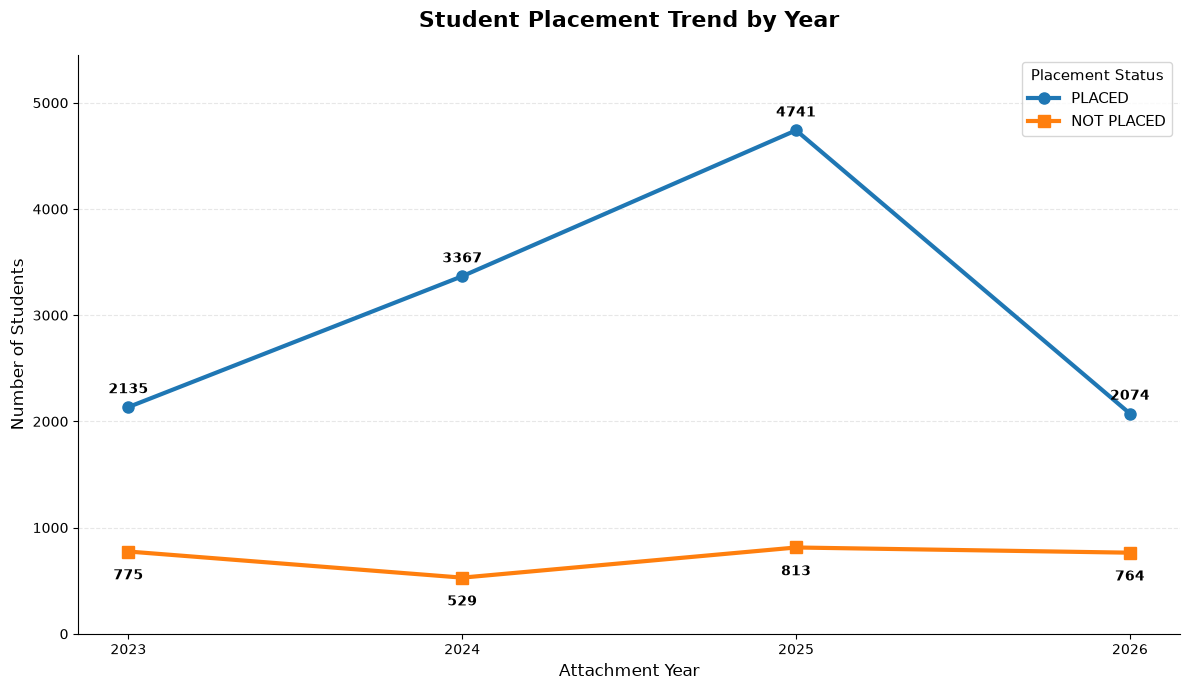

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REMOVE RECORDS WHERE ATTACHMENT START YEAR IS MISSING
# ============================================================

trend_df = df.dropna(
    subset=['attachment_start_year']
).copy()


# ============================================================
# 2. MAKE SURE YEAR IS NUMERIC
# ============================================================

trend_df['attachment_start_year'] = pd.to_numeric(
    trend_df['attachment_start_year'],
    errors='coerce'
)


# Remove any records that became missing after conversion

trend_df = trend_df.dropna(
    subset=['attachment_start_year']
)


# Convert year to integer

trend_df['attachment_start_year'] = (
    trend_df['attachment_start_year']
    .astype(int)
)


# ============================================================
# 3. COUNT PLACED AND NOT PLACED STUDENTS PER YEAR
# ============================================================

placement_trend = (
    trend_df
    .groupby(
        [
            'attachment_start_year',
            'placement_status'
        ]
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 4. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'PLACED' not in placement_trend.columns:
    placement_trend['PLACED'] = 0

if 'NOT PLACED' not in placement_trend.columns:
    placement_trend['NOT PLACED'] = 0


# ============================================================
# 5. SORT YEARS
# ============================================================

placement_trend = placement_trend.sort_index()


# ============================================================
# 6. DISPLAY THE SUMMARY TABLE
# ============================================================

print("PLACEMENT TREND BY YEAR")

display(
    placement_trend[
        ['PLACED', 'NOT PLACED']
    ]
)


# ============================================================
# 7. CREATE THE LINE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)


# ============================================================
# 8. PLOT PLACED STUDENTS
# ============================================================

ax.plot(
    placement_trend.index,
    placement_trend['PLACED'],
    marker='o',
    linewidth=3,
    markersize=8,
    label='PLACED'
)


# ============================================================
# 9. PLOT NOT PLACED STUDENTS
# ============================================================

ax.plot(
    placement_trend.index,
    placement_trend['NOT PLACED'],
    marker='s',
    linewidth=3,
    markersize=8,
    label='NOT PLACED'
)


# ============================================================
# 10. ADD VALUES TO PLACED LINE
# ============================================================

for x, y in zip(
    placement_trend.index,
    placement_trend['PLACED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 11. ADD VALUES TO NOT PLACED LINE
# ============================================================

for x, y in zip(
    placement_trend.index,
    placement_trend['NOT PLACED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, -20),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 12. TITLE
# ============================================================

ax.set_title(
    'Student Placement Trend by Year',
    fontsize=16,
    fontweight='bold',
    pad=20
)


# ============================================================
# 13. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Year',
    fontsize=12
)

ax.set_ylabel(
    'Number of Students',
    fontsize=12
)


# ============================================================
# 14. SHOW ALL YEARS ON X-AXIS
# ============================================================

ax.set_xticks(
    placement_trend.index
)

ax.set_xticklabels(
    placement_trend.index,
    rotation=0
)


# ============================================================
# 15. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 16. ADD LEGEND
# ============================================================

ax.legend(
    title='Placement Status',
    fontsize=11,
    title_fontsize=11
)


# ============================================================
# 17. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 18. ADD SOME SPACE ABOVE THE HIGHEST VALUE
# ============================================================

max_value = placement_trend[
    ['PLACED', 'NOT PLACED']
].max().max()

ax.set_ylim(
    0,
    max_value * 1.15
)


# ============================================================
# 19. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 20. DISPLAY GRAPH
# ============================================================

plt.show()

GRADING STATUS BY YEAR


graded,GRADED,NOT GRADED,TOTAL,GRADED_PERCENT,NOT_GRADED_PERCENT
attachment_start_year,,,,,
2023,232,2678,2910,7.972509,92.027491
2024,1841,2055,3896,47.253593,52.746407
2025,3376,2178,5554,60.785020,39.214980
2026,1700,1138,2838,59.901339,40.098661


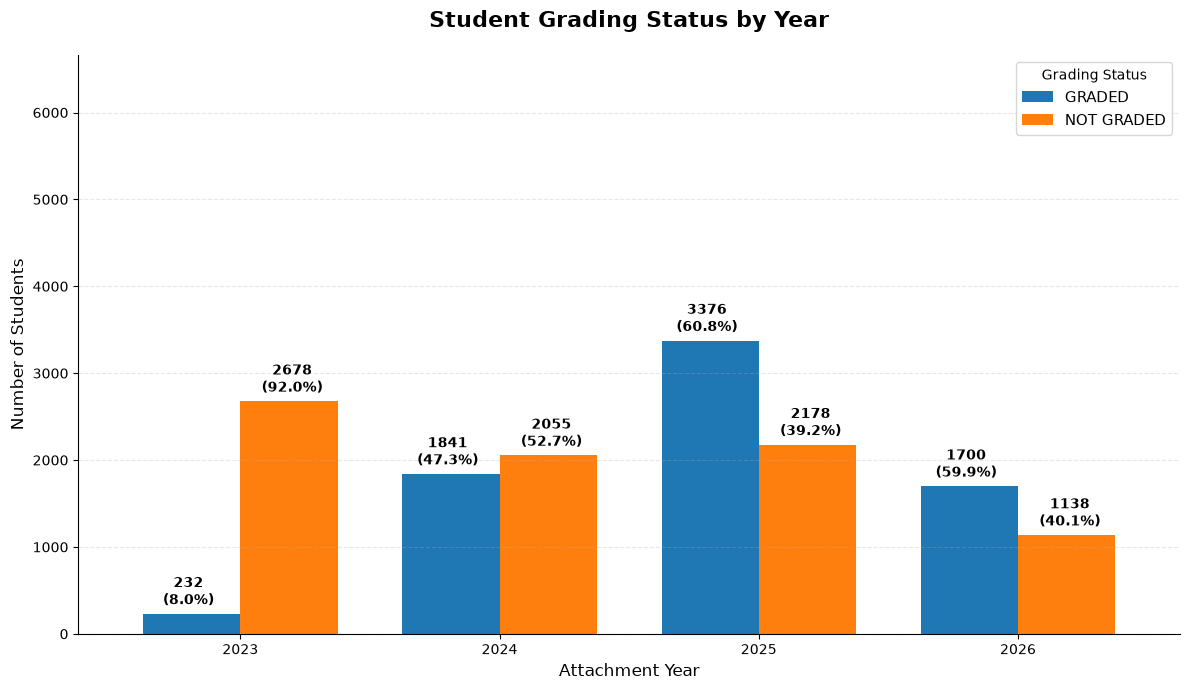

In [14]:
#GRAPH OF PLACEMENT VS GRADING
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. REMOVE RECORDS WHERE ATTACHMENT START YEAR IS MISSING
# ============================================================

grading_df = df.dropna(
    subset=['attachment_start_year']
).copy()


# ============================================================
# 2. CONVERT ATTACHMENT START YEAR TO INTEGER
# ============================================================

grading_df['attachment_start_year'] = pd.to_numeric(
    grading_df['attachment_start_year'],
    errors='coerce'
)

grading_df = grading_df.dropna(
    subset=['attachment_start_year']
)

grading_df['attachment_start_year'] = (
    grading_df['attachment_start_year'].astype(int)
)


# ============================================================
# 3. STANDARDIZE THE GRADED COLUMN
# ============================================================

grading_df['graded'] = (
    grading_df['graded']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. COUNT GRADED AND NOT GRADED STUDENTS PER YEAR
# ============================================================

grading_summary = (
    grading_df
    .groupby(
        ['attachment_start_year', 'graded']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 5. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'GRADED' not in grading_summary.columns:
    grading_summary['GRADED'] = 0

if 'NOT GRADED' not in grading_summary.columns:
    grading_summary['NOT GRADED'] = 0


# ============================================================
# 6. SORT BY YEAR
# ============================================================

grading_summary = grading_summary.sort_index()


# ============================================================
# 7. CALCULATE TOTAL STUDENTS PER YEAR
# ============================================================

grading_summary['TOTAL'] = (
    grading_summary['GRADED'] +
    grading_summary['NOT GRADED']
)


# ============================================================
# 8. CALCULATE PERCENTAGES
# ============================================================

grading_summary['GRADED_PERCENT'] = (
    grading_summary['GRADED'] /
    grading_summary['TOTAL'] * 100
)

grading_summary['NOT_GRADED_PERCENT'] = (
    grading_summary['NOT GRADED'] /
    grading_summary['TOTAL'] * 100
)


# ============================================================
# 9. DISPLAY SUMMARY TABLE
# ============================================================

print("GRADING STATUS BY YEAR")

display(grading_summary)


# ============================================================
# 10. PREPARE DATA FOR CHART
# ============================================================

chart_data = grading_summary[
    ['GRADED', 'NOT GRADED']
]


# ============================================================
# 11. CREATE BAR CHART
# ============================================================

ax = chart_data.plot(
    kind='bar',
    figsize=(12, 7),
    width=0.75
)


# ============================================================
# 12. TITLE AND AXIS LABELS
# ============================================================

plt.title(
    'Student Grading Status by Year',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Attachment Year',
    fontsize=12
)

plt.ylabel(
    'Number of Students',
    fontsize=12
)


# ============================================================
# 13. KEEP YEAR LABELS HORIZONTAL
# ============================================================

plt.xticks(rotation=0)


# ============================================================
# 14. ADD LEGEND
# ============================================================

plt.legend(
    title='Grading Status',
    fontsize=11
)


# ============================================================
# 15. ADD COUNT AND PERCENTAGE TO EACH BAR
# ============================================================

for i, year in enumerate(grading_summary.index):

    # ----------------------------
    # GRADED
    # ----------------------------

    graded_count = grading_summary.loc[
        year, 'GRADED'
    ]

    graded_percent = grading_summary.loc[
        year, 'GRADED_PERCENT'
    ]

    # Position of GRADED bar
    ax.text(
        i - 0.20,
        graded_count + (grading_summary['TOTAL'].max() * 0.01),
        f'{int(graded_count)}\n({graded_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


    # ----------------------------
    # NOT GRADED
    # ----------------------------

    not_graded_count = grading_summary.loc[
        year, 'NOT GRADED'
    ]

    not_graded_percent = grading_summary.loc[
        year, 'NOT_GRADED_PERCENT'
    ]

    # Position of NOT GRADED bar
    ax.text(
        i + 0.20,
        not_graded_count + (grading_summary['TOTAL'].max() * 0.01),
        f'{int(not_graded_count)}\n({not_graded_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 16. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 17. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 18. ADD SPACE ABOVE BARS FOR LABELS
# ============================================================

ax.set_ylim(
    0,
    grading_summary['TOTAL'].max() * 1.20
)


# ============================================================
# 19. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 20. DISPLAY CHART
# ============================================================

plt.show()

GRADING TREND BY YEAR


graded,GRADED,NOT GRADED
attachment_start_year,,
2023,232,2678
2024,1841,2055
2025,3376,2178
2026,1700,1138


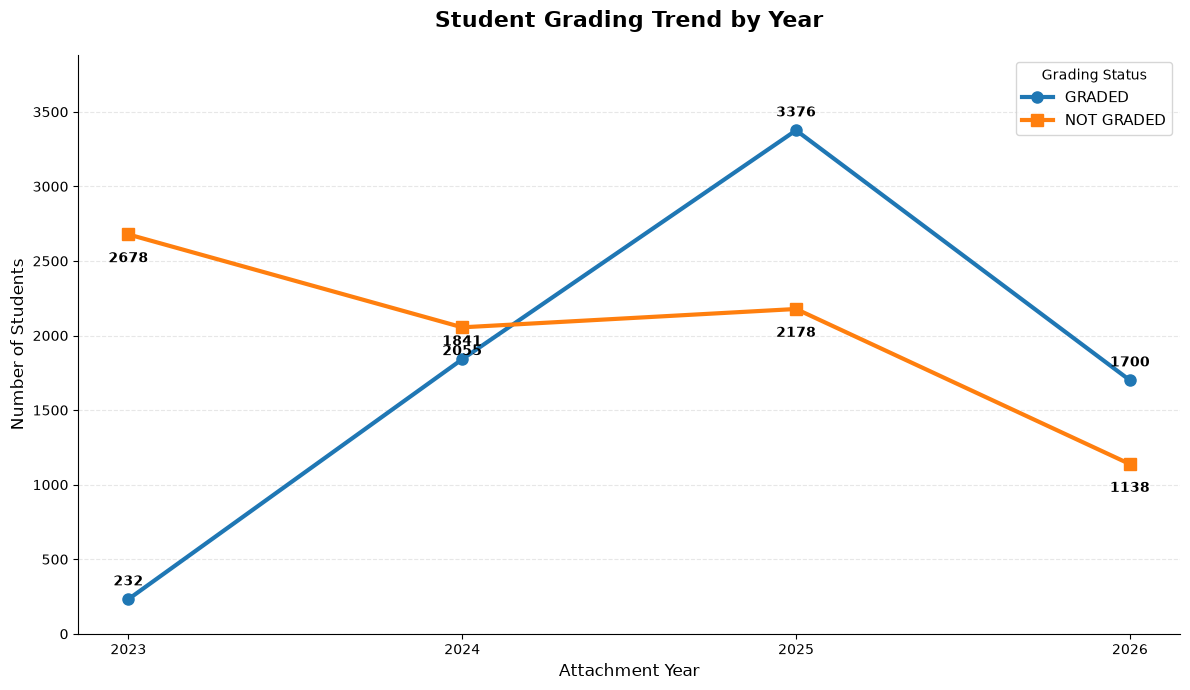

In [16]:
#GRADING TREND
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PREPARE THE DATA
# ============================================================

grading_df = df.dropna(
    subset=['attachment_start_year']
).copy()


# ============================================================
# 2. CONVERT YEAR TO INTEGER
# ============================================================

grading_df['attachment_start_year'] = pd.to_numeric(
    grading_df['attachment_start_year'],
    errors='coerce'
)

grading_df = grading_df.dropna(
    subset=['attachment_start_year']
)

grading_df['attachment_start_year'] = (
    grading_df['attachment_start_year'].astype(int)
)


# ============================================================
# 3. STANDARDIZE GRADED VALUES
# ============================================================

grading_df['graded'] = (
    grading_df['graded']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. COUNT GRADED AND NOT GRADED PER YEAR
# ============================================================

grading_trend = (
    grading_df
    .groupby(
        ['attachment_start_year', 'graded']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 5. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'GRADED' not in grading_trend.columns:
    grading_trend['GRADED'] = 0

if 'NOT GRADED' not in grading_trend.columns:
    grading_trend['NOT GRADED'] = 0


# ============================================================
# 6. SORT BY YEAR
# ============================================================

grading_trend = grading_trend.sort_index()


# ============================================================
# 7. DISPLAY SUMMARY
# ============================================================

print("GRADING TREND BY YEAR")

display(
    grading_trend[
        ['GRADED', 'NOT GRADED']
    ]
)


# ============================================================
# 8. CREATE LINE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)


# ============================================================
# 9. PLOT GRADED LINE
# ============================================================

ax.plot(
    grading_trend.index,
    grading_trend['GRADED'],
    marker='o',
    linewidth=3,
    markersize=8,
    label='GRADED'
)


# ============================================================
# 10. PLOT NOT GRADED LINE
# ============================================================

ax.plot(
    grading_trend.index,
    grading_trend['NOT GRADED'],
    marker='s',
    linewidth=3,
    markersize=8,
    label='NOT GRADED'
)


# ============================================================
# 11. ADD VALUES TO GRADED LINE
# ============================================================

for x, y in zip(
    grading_trend.index,
    grading_trend['GRADED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 12. ADD VALUES TO NOT GRADED LINE
# ============================================================

for x, y in zip(
    grading_trend.index,
    grading_trend['NOT GRADED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, -20),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 13. TITLE
# ============================================================

ax.set_title(
    'Student Grading Trend by Year',
    fontsize=16,
    fontweight='bold',
    pad=20
)


# ============================================================
# 14. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Year',
    fontsize=12
)

ax.set_ylabel(
    'Number of Students',
    fontsize=12
)


# ============================================================
# 15. SHOW YEARS ON X-AXIS
# ============================================================

ax.set_xticks(
    grading_trend.index
)

ax.set_xticklabels(
    grading_trend.index,
    rotation=0
)


# ============================================================
# 16. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 17. ADD LEGEND
# ============================================================

ax.legend(
    title='Grading Status',
    fontsize=11
)


# ============================================================
# 18. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 19. ADD SPACE ABOVE THE HIGHEST POINT
# ============================================================

max_value = grading_trend[
    ['GRADED', 'NOT GRADED']
].max().max()

ax.set_ylim(
    0,
    max_value * 1.15
)


# ============================================================
# 20. FINAL LAYOUT AND DISPLAY
# ============================================================

plt.tight_layout()
plt.show()

PLACEMENT SUMMARY BY ATTACHMENT PERIOD


placement_status,PLACED,NOT PLACED,TOTAL,PLACED_PERCENT,NOT_PLACED_PERCENT
attachment_period,,,,,
APR-JUN,16,0,16,100.000000,0.000000
AUG-DEC,127,7,134,94.776119,5.223881
AUG-OCT,10,1,11,90.909091,9.090909
JAN-APR,3023,946,3969,76.165281,23.834719
JUL-AUG,10,0,10,100.000000,0.000000
MAY-AUG,3372,840,4212,80.056980,19.943020
NOV-DEC,22,2,24,91.666667,8.333333
SEP-DEC,4006,380,4386,91.336069,8.663931
SEP-NOV,1731,705,2436,71.059113,28.940887


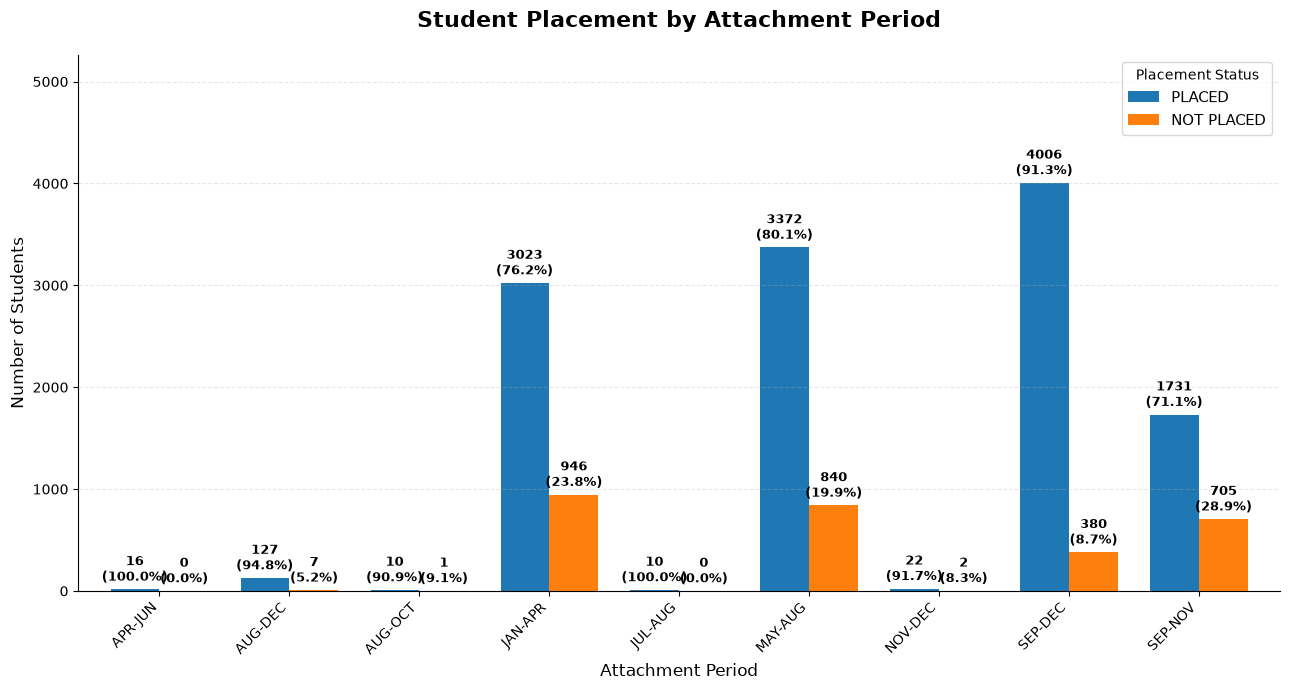

In [17]:
#PLACEMENT BY ATTACHMENT PERIOD
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE A COPY FOR THE ANALYSIS
# ============================================================

placement_df = df.copy()


# ============================================================
# 2. REMOVE RECORDS WHERE ATTACHMENT PERIOD IS MISSING
# ============================================================

placement_df = placement_df.dropna(
    subset=['attachment_period']
)


# ============================================================
# 3. STANDARDIZE ATTACHMENT PERIOD
# ============================================================

placement_df['attachment_period'] = (
    placement_df['attachment_period']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. STANDARDIZE PLACEMENT STATUS
# ============================================================

placement_df['placement_status'] = (
    placement_df['placement_status']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. COUNT PLACED AND NOT PLACED PER ATTACHMENT PERIOD
# ============================================================

placement_summary = (
    placement_df
    .groupby(
        ['attachment_period', 'placement_status']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 6. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'PLACED' not in placement_summary.columns:
    placement_summary['PLACED'] = 0

if 'NOT PLACED' not in placement_summary.columns:
    placement_summary['NOT PLACED'] = 0


# ============================================================
# 7. KEEP ONLY THE TWO REQUIRED CATEGORIES
# ============================================================

placement_summary = placement_summary[
    ['PLACED', 'NOT PLACED']
]


# ============================================================
# 8. CALCULATE TOTAL STUDENTS
# ============================================================

placement_summary['TOTAL'] = (
    placement_summary['PLACED'] +
    placement_summary['NOT PLACED']
)


# ============================================================
# 9. CALCULATE PERCENTAGES
# ============================================================

placement_summary['PLACED_PERCENT'] = (
    placement_summary['PLACED'] /
    placement_summary['TOTAL'] * 100
)

placement_summary['NOT_PLACED_PERCENT'] = (
    placement_summary['NOT PLACED'] /
    placement_summary['TOTAL'] * 100
)


# ============================================================
# 10. DISPLAY SUMMARY TABLE
# ============================================================

print("PLACEMENT SUMMARY BY ATTACHMENT PERIOD")

display(placement_summary)


# ============================================================
# 11. PREPARE DATA FOR THE BAR CHART
# ============================================================

chart_data = placement_summary[
    ['PLACED', 'NOT PLACED']
]


# ============================================================
# 12. CREATE BAR CHART
# ============================================================

ax = chart_data.plot(
    kind='bar',
    figsize=(13, 7),
    width=0.75
)


# ============================================================
# 13. TITLE
# ============================================================

plt.title(
    'Student Placement by Attachment Period',
    fontsize=16,
    fontweight='bold',
    pad=20
)


# ============================================================
# 14. AXIS LABELS
# ============================================================

plt.xlabel(
    'Attachment Period',
    fontsize=12
)

plt.ylabel(
    'Number of Students',
    fontsize=12
)


# ============================================================
# 15. FORMAT X-AXIS
# ============================================================

plt.xticks(
    rotation=45,
    ha='right'
)


# ============================================================
# 16. LEGEND
# ============================================================

plt.legend(
    title='Placement Status',
    fontsize=11
)


# ============================================================
# 17. ADD COUNT AND PERCENTAGE TO EACH BAR
# ============================================================

max_total = placement_summary['TOTAL'].max()

for i, period in enumerate(placement_summary.index):

    # --------------------------------------------------------
    # PLACED
    # --------------------------------------------------------

    placed_count = placement_summary.loc[
        period, 'PLACED'
    ]

    placed_percent = placement_summary.loc[
        period, 'PLACED_PERCENT'
    ]

    ax.text(
        i - 0.19,
        placed_count + (max_total * 0.01),
        f'{int(placed_count)}\n({placed_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )


    # --------------------------------------------------------
    # NOT PLACED
    # --------------------------------------------------------

    not_placed_count = placement_summary.loc[
        period, 'NOT PLACED'
    ]

    not_placed_percent = placement_summary.loc[
        period, 'NOT_PLACED_PERCENT'
    ]

    ax.text(
        i + 0.19,
        not_placed_count + (max_total * 0.01),
        f'{int(not_placed_count)}\n({not_placed_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )


# ============================================================
# 18. ADD HORIZONTAL GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 19. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 20. ADD SPACE ABOVE BARS FOR LABELS
# ============================================================

ax.set_ylim(
    0,
    max_total * 1.20
)


# ============================================================
# 21. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 22. DISPLAY CHART
# ============================================================

plt.show()

PLACEMENT TREND BY ATTACHMENT PERIOD


placement_status,PLACED,NOT PLACED
attachment_period,,
APR-JUN,16,0
AUG-DEC,127,7
AUG-OCT,10,1
JAN-APR,3023,946
JUL-AUG,10,0
MAY-AUG,3372,840
NOV-DEC,22,2
SEP-DEC,4006,380
SEP-NOV,1731,705


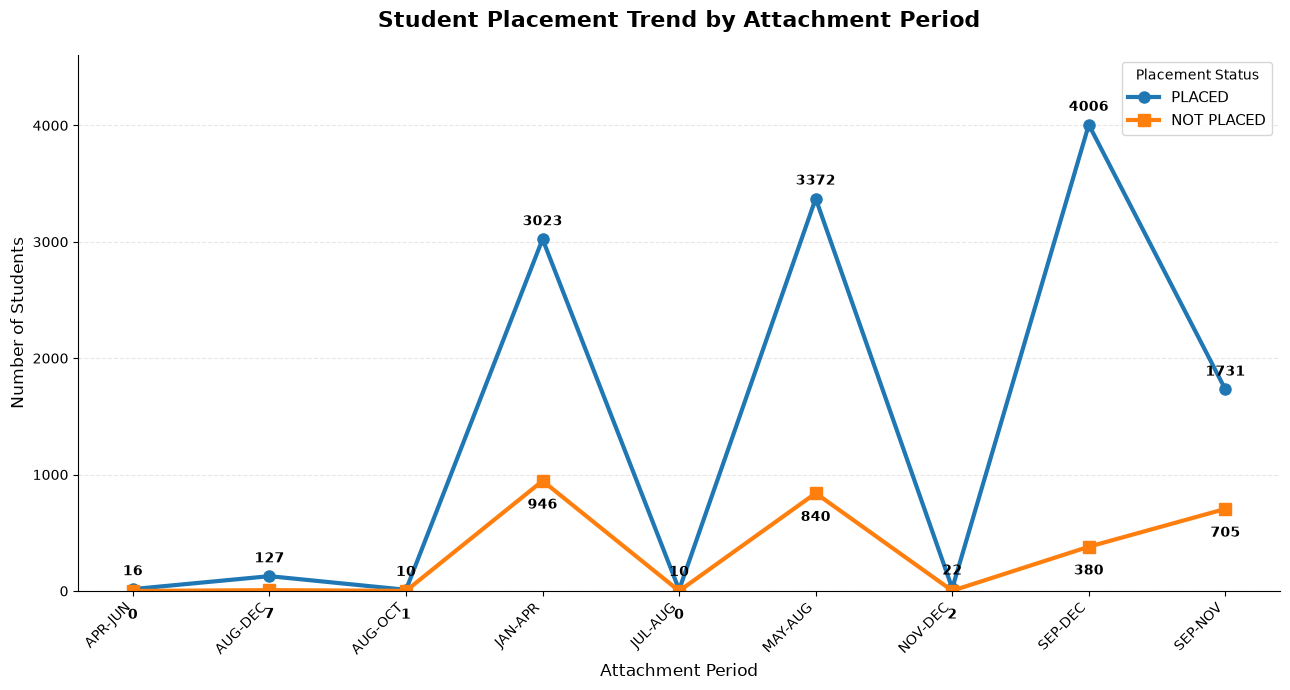

In [18]:
#PLACEMENT TREND PER ATTACHMENT PERIOD
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE COPY FOR ANALYSIS
# ============================================================

placement_df = df.copy()


# ============================================================
# 2. REMOVE MISSING ATTACHMENT PERIODS
# ============================================================

placement_df = placement_df.dropna(
    subset=['attachment_period']
)


# ============================================================
# 3. STANDARDIZE ATTACHMENT PERIOD
# ============================================================

placement_df['attachment_period'] = (
    placement_df['attachment_period']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. STANDARDIZE PLACEMENT STATUS
# ============================================================

placement_df['placement_status'] = (
    placement_df['placement_status']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. COUNT PLACED AND NOT PLACED PER ATTACHMENT PERIOD
# ============================================================

placement_trend = (
    placement_df
    .groupby(
        ['attachment_period', 'placement_status']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 6. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'PLACED' not in placement_trend.columns:
    placement_trend['PLACED'] = 0

if 'NOT PLACED' not in placement_trend.columns:
    placement_trend['NOT PLACED'] = 0


# ============================================================
# 7. KEEP ONLY PLACED AND NOT PLACED
# ============================================================

placement_trend = placement_trend[
    ['PLACED', 'NOT PLACED']
]


# ============================================================
# 8. DISPLAY SUMMARY TABLE
# ============================================================

print("PLACEMENT TREND BY ATTACHMENT PERIOD")

display(placement_trend)


# ============================================================
# 9. CREATE LINE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 7)
)


# ============================================================
# 10. PLOT PLACED LINE
# ============================================================

ax.plot(
    placement_trend.index,
    placement_trend['PLACED'],
    marker='o',
    linewidth=3,
    markersize=8,
    label='PLACED'
)


# ============================================================
# 11. PLOT NOT PLACED LINE
# ============================================================

ax.plot(
    placement_trend.index,
    placement_trend['NOT PLACED'],
    marker='s',
    linewidth=3,
    markersize=8,
    label='NOT PLACED'
)


# ============================================================
# 12. ADD VALUES TO PLACED LINE
# ============================================================

for x, y in zip(
    placement_trend.index,
    placement_trend['PLACED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 13. ADD VALUES TO NOT PLACED LINE
# ============================================================

for x, y in zip(
    placement_trend.index,
    placement_trend['NOT PLACED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, -20),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )


# ============================================================
# 14. TITLE
# ============================================================

ax.set_title(
    'Student Placement Trend by Attachment Period',
    fontsize=16,
    fontweight='bold',
    pad=20
)


# ============================================================
# 15. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Period',
    fontsize=12
)

ax.set_ylabel(
    'Number of Students',
    fontsize=12
)


# ============================================================
# 16. FORMAT X-AXIS
# ============================================================

ax.set_xticks(
    range(len(placement_trend.index))
)

ax.set_xticklabels(
    placement_trend.index,
    rotation=45,
    ha='right'
)


# ============================================================
# 17. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 18. ADD LEGEND
# ============================================================

ax.legend(
    title='Placement Status',
    fontsize=11
)


# ============================================================
# 19. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 20. ADD SPACE ABOVE HIGHEST VALUE
# ============================================================

max_value = placement_trend[
    ['PLACED', 'NOT PLACED']
].max().max()

ax.set_ylim(
    0,
    max_value * 1.15
)


# ============================================================
# 21. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 22. DISPLAY GRAPH
# ============================================================

plt.show()

GRADING SUMMARY BY ATTACHMENT PERIOD


graded,GRADED,NOT GRADED,TOTAL,GRADED_PERCENT,NOT_GRADED_PERCENT
attachment_period,,,,,
APR-JUN,0,16,16,0.000000,100.000000
AUG-DEC,61,73,134,45.522388,54.477612
AUG-OCT,0,11,11,0.000000,100.000000
JAN-APR,2003,1966,3969,50.466112,49.533888
JUL-AUG,0,10,10,0.000000,100.000000
MAY-AUG,2462,1750,4212,58.452042,41.547958
NOV-DEC,7,17,24,29.166667,70.833333
SEP-DEC,2529,1857,4386,57.660739,42.339261
SEP-NOV,87,2349,2436,3.571429,96.428571


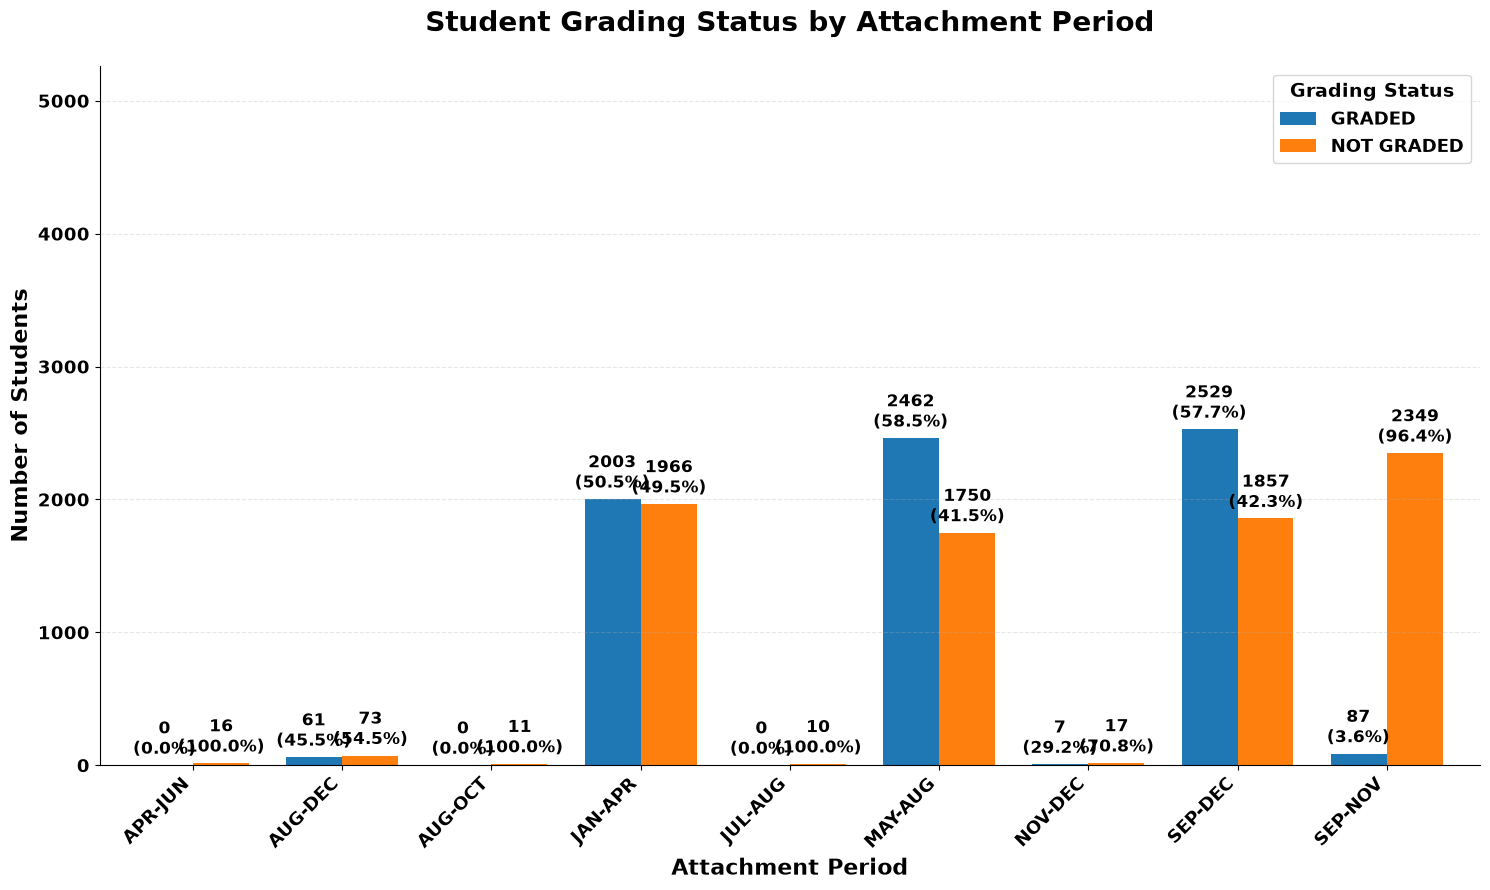

In [19]:
#BARCHART OF GRADING: GRADED VS NOT GRADED
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE COPY FOR ANALYSIS
# ============================================================

grading_df = df.copy()


# ============================================================
# 2. REMOVE MISSING ATTACHMENT PERIODS
# ============================================================

grading_df = grading_df.dropna(
    subset=['attachment_period']
).copy()


# ============================================================
# 3. STANDARDIZE ATTACHMENT PERIOD
# ============================================================

grading_df['attachment_period'] = (
    grading_df['attachment_period']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. STANDARDIZE GRADED COLUMN
# ============================================================

grading_df['graded'] = (
    grading_df['graded']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. COUNT GRADED AND NOT GRADED
#    PER ATTACHMENT PERIOD
# ============================================================

grading_summary = (
    grading_df
    .groupby(
        ['attachment_period', 'graded']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 6. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'GRADED' not in grading_summary.columns:
    grading_summary['GRADED'] = 0

if 'NOT GRADED' not in grading_summary.columns:
    grading_summary['NOT GRADED'] = 0


# ============================================================
# 7. KEEP ONLY REQUIRED COLUMNS
# ============================================================

grading_summary = grading_summary[
    ['GRADED', 'NOT GRADED']
]


# ============================================================
# 8. CALCULATE TOTAL STUDENTS
# ============================================================

grading_summary['TOTAL'] = (
    grading_summary['GRADED'] +
    grading_summary['NOT GRADED']
)


# ============================================================
# 9. CALCULATE PERCENTAGES
# ============================================================

grading_summary['GRADED_PERCENT'] = (
    grading_summary['GRADED'] /
    grading_summary['TOTAL'] * 100
)

grading_summary['NOT_GRADED_PERCENT'] = (
    grading_summary['NOT GRADED'] /
    grading_summary['TOTAL'] * 100
)


# ============================================================
# 10. DISPLAY SUMMARY TABLE
# ============================================================

print("GRADING SUMMARY BY ATTACHMENT PERIOD")

display(grading_summary)


# ============================================================
# 11. PREPARE CHART DATA
# ============================================================

chart_data = grading_summary[
    ['GRADED', 'NOT GRADED']
]


# ============================================================
# 12. CREATE BAR CHART
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 9)
)

bars = chart_data.plot(
    kind='bar',
    ax=ax,
    width=0.75
)


# ============================================================
# 13. TITLE
# ============================================================

ax.set_title(
    'Student Grading Status by Attachment Period',
    fontsize=20,
    fontweight='bold',
    pad=25
)


# ============================================================
# 14. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Period',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Students',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# 15. X-AXIS TEXT
# ============================================================

ax.tick_params(
    axis='x',
    labelsize=13
)

ax.tick_params(
    axis='y',
    labelsize=13
)

plt.xticks(
    rotation=45,
    ha='right',
    fontweight='bold'
)


# ============================================================
# 16. Y-AXIS LABELS BOLD
# ============================================================

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


# ============================================================
# 17. LEGEND
# ============================================================

legend = ax.legend(
    title='Grading Status',
    fontsize=13,
    title_fontsize=14
)

for text in legend.get_texts():
    text.set_fontweight('bold')

legend.get_title().set_fontweight('bold')


# ============================================================
# 18. ADD COUNT + PERCENTAGE TO BARS
# ============================================================

max_total = grading_summary['TOTAL'].max()

for i, period in enumerate(grading_summary.index):

    # --------------------------------------------------------
    # GRADED
    # --------------------------------------------------------

    graded_count = grading_summary.loc[
        period,
        'GRADED'
    ]

    graded_percent = grading_summary.loc[
        period,
        'GRADED_PERCENT'
    ]

    ax.text(
        i - 0.19,
        graded_count + (max_total * 0.01),
        f'{int(graded_count)}\n({graded_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )


    # --------------------------------------------------------
    # NOT GRADED
    # --------------------------------------------------------

    not_graded_count = grading_summary.loc[
        period,
        'NOT GRADED'
    ]

    not_graded_percent = grading_summary.loc[
        period,
        'NOT_GRADED_PERCENT'
    ]

    ax.text(
        i + 0.19,
        not_graded_count + (max_total * 0.01),
        f'{int(not_graded_count)}\n({not_graded_percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )


# ============================================================
# 19. ADD GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 20. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 21. ADD SPACE ABOVE BARS
# ============================================================

ax.set_ylim(
    0,
    max_total * 1.20
)


# ============================================================
# 22. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 23. DISPLAY GRAPH
# ============================================================

plt.show()

GRADING TREND BY ATTACHMENT PERIOD


graded,GRADED,NOT GRADED
attachment_period,,
APR-JUN,0,16
AUG-DEC,61,73
AUG-OCT,0,11
JAN-APR,2003,1966
JUL-AUG,0,10
MAY-AUG,2462,1750
NOV-DEC,7,17
SEP-DEC,2529,1857
SEP-NOV,87,2349


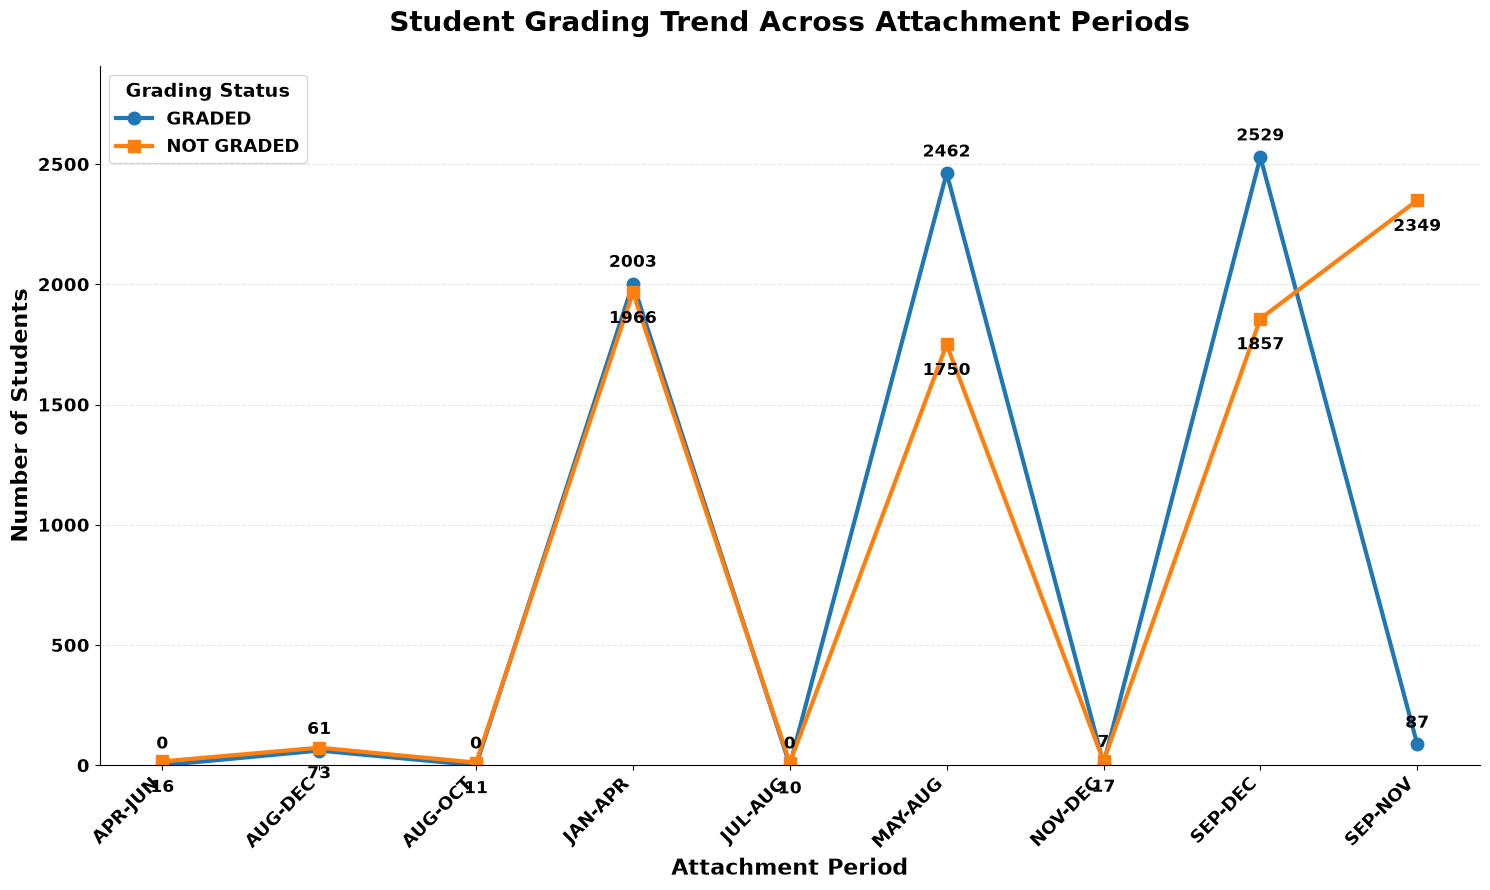

In [20]:
#GRADING TREND ACROSS ATTACHMENT PERIOD
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CREATE COPY FOR ANALYSIS
# ============================================================

grading_df = df.copy()


# ============================================================
# 2. REMOVE MISSING ATTACHMENT PERIODS
# ============================================================

grading_df = grading_df.dropna(
    subset=['attachment_period']
).copy()


# ============================================================
# 3. STANDARDIZE ATTACHMENT PERIOD
# ============================================================

grading_df['attachment_period'] = (
    grading_df['attachment_period']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. STANDARDIZE GRADED VALUES
# ============================================================

grading_df['graded'] = (
    grading_df['graded']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. COUNT GRADED AND NOT GRADED
#    PER ATTACHMENT PERIOD
# ============================================================

grading_trend = (
    grading_df
    .groupby(
        ['attachment_period', 'graded']
    )
    .size()
    .unstack(fill_value=0)
)


# ============================================================
# 6. MAKE SURE BOTH CATEGORIES EXIST
# ============================================================

if 'GRADED' not in grading_trend.columns:
    grading_trend['GRADED'] = 0

if 'NOT GRADED' not in grading_trend.columns:
    grading_trend['NOT GRADED'] = 0


# ============================================================
# 7. KEEP ONLY THE TWO CATEGORIES
# ============================================================

grading_trend = grading_trend[
    ['GRADED', 'NOT GRADED']
]


# ============================================================
# 8. DISPLAY SUMMARY TABLE
# ============================================================

print("GRADING TREND BY ATTACHMENT PERIOD")

display(grading_trend)


# ============================================================
# 9. CREATE LINE GRAPH
# ============================================================

fig, ax = plt.subplots(
    figsize=(15, 9)
)


# ============================================================
# 10. PLOT GRADED
# ============================================================

ax.plot(
    grading_trend.index,
    grading_trend['GRADED'],
    marker='o',
    linewidth=3,
    markersize=9,
    label='GRADED'
)


# ============================================================
# 11. PLOT NOT GRADED
# ============================================================

ax.plot(
    grading_trend.index,
    grading_trend['NOT GRADED'],
    marker='s',
    linewidth=3,
    markersize=9,
    label='NOT GRADED'
)


# ============================================================
# 12. ADD VALUES TO GRADED LINE
# ============================================================

for x, y in zip(
    grading_trend.index,
    grading_trend['GRADED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )


# ============================================================
# 13. ADD VALUES TO NOT GRADED LINE
# ============================================================

for x, y in zip(
    grading_trend.index,
    grading_trend['NOT GRADED']
):

    ax.annotate(
        f'{int(y)}',
        (x, y),
        xytext=(0, -22),
        textcoords='offset points',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )


# ============================================================
# 14. TITLE
# ============================================================

ax.set_title(
    'Student Grading Trend Across Attachment Periods',
    fontsize=20,
    fontweight='bold',
    pad=25
)


# ============================================================
# 15. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Period',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Students',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# 16. X-AXIS FORMATTING
# ============================================================

ax.set_xticks(
    range(len(grading_trend.index))
)

ax.set_xticklabels(
    grading_trend.index,
    rotation=45,
    ha='right',
    fontsize=13,
    fontweight='bold'
)


# ============================================================
# 17. Y-AXIS FORMATTING
# ============================================================

ax.tick_params(
    axis='y',
    labelsize=13
)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


# ============================================================
# 18. GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 19. LEGEND
# ============================================================

legend = ax.legend(
    title='Grading Status',
    fontsize=13,
    title_fontsize=14
)

for text in legend.get_texts():
    text.set_fontweight('bold')

legend.get_title().set_fontweight('bold')


# ============================================================
# 20. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 21. ADD SPACE ABOVE HIGHEST POINT
# ============================================================

max_value = grading_trend[
    ['GRADED', 'NOT GRADED']
].max().max()

ax.set_ylim(
    0,
    max_value * 1.15
)


# ============================================================
# 22. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 23. DISPLAY GRAPH
# ============================================================

plt.show()

PLACEMENT BY GENDER AND YEAR


placement_status,attachment_start_year,student_gender,NOT PLACED,PLACED,TOTAL,PLACED_PERCENT,NOT_PLACED_PERCENT
0,2023,FEMALE,262.0,1004.0,1266.0,79.304897,20.695103
1,2023,MALE,464.0,1021.0,1485.0,68.754209,31.245791
2,2024,FEMALE,242.0,1488.0,1730.0,86.011561,13.988439
3,2024,MALE,259.0,1771.0,2030.0,87.241379,12.758621
4,2025,FEMALE,260.0,2048.0,2308.0,88.734835,11.265165
5,2025,MALE,497.0,2561.0,3058.0,83.747547,16.252453
6,2026,FEMALE,213.0,905.0,1118.0,80.948122,19.051878
7,2026,MALE,511.0,1169.0,1680.0,69.583333,30.416667


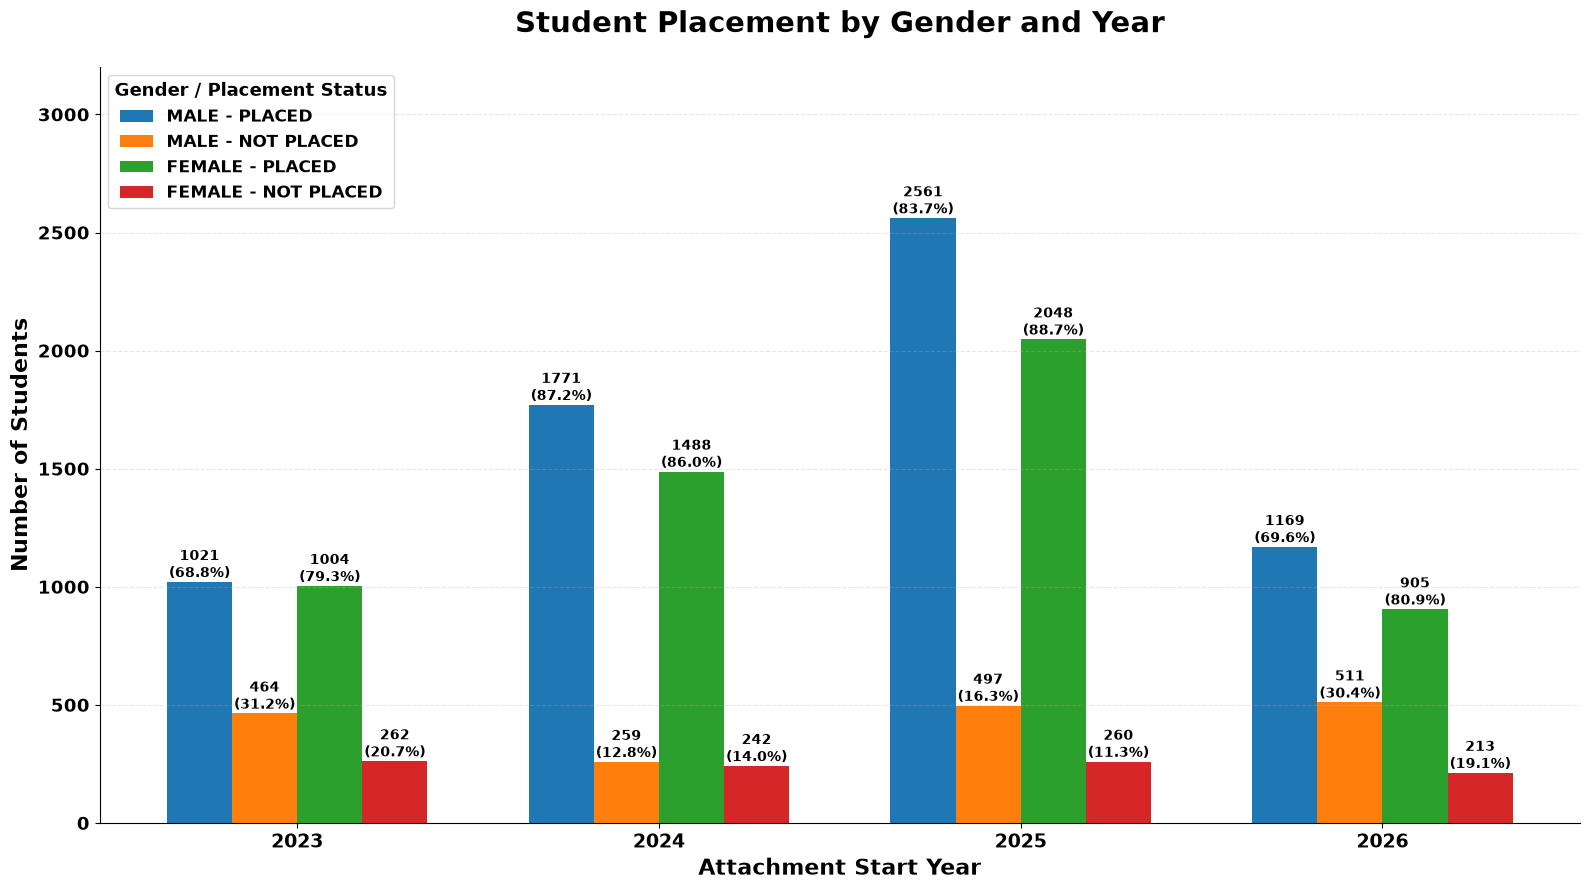

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# 1. CREATE COPY FOR ANALYSIS
# ============================================================

placement_gender_df = df.copy()


# ============================================================
# 2. REMOVE RECORDS WITH MISSING VALUES
# ============================================================

placement_gender_df = placement_gender_df.dropna(
    subset=[
        'student_gender',
        'attachment_start_year',
        'placement_status'
    ]
).copy()


# ============================================================
# 3. STANDARDIZE GENDER
# ============================================================

placement_gender_df['student_gender'] = (
    placement_gender_df['student_gender']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 4. STANDARDIZE PLACEMENT STATUS
# ============================================================

placement_gender_df['placement_status'] = (
    placement_gender_df['placement_status']
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 5. CONVERT YEAR TO INTEGER
# ============================================================

placement_gender_df['attachment_start_year'] = pd.to_numeric(
    placement_gender_df['attachment_start_year'],
    errors='coerce'
)

placement_gender_df = placement_gender_df.dropna(
    subset=['attachment_start_year']
)

placement_gender_df['attachment_start_year'] = (
    placement_gender_df['attachment_start_year']
    .astype(int)
)


# ============================================================
# 6. KEEP ONLY MALE AND FEMALE
# ============================================================

placement_gender_df = placement_gender_df[
    placement_gender_df['student_gender'].isin(
        ['MALE', 'FEMALE']
    )
]


# ============================================================
# 7. COUNT STUDENTS
# ============================================================

summary = (
    placement_gender_df
    .groupby(
        [
            'attachment_start_year',
            'student_gender',
            'placement_status'
        ]
    )
    .size()
    .reset_index(name='student_count')
)


# ============================================================
# 8. CREATE PIVOT TABLE
# ============================================================

summary_pivot = (
    summary
    .pivot_table(
        index=[
            'attachment_start_year',
            'student_gender'
        ],
        columns='placement_status',
        values='student_count',
        fill_value=0
    )
    .reset_index()
)


# ============================================================
# 9. MAKE SURE BOTH STATUS COLUMNS EXIST
# ============================================================

if 'PLACED' not in summary_pivot.columns:
    summary_pivot['PLACED'] = 0

if 'NOT PLACED' not in summary_pivot.columns:
    summary_pivot['NOT PLACED'] = 0


# ============================================================
# 10. CALCULATE TOTAL
# ============================================================

summary_pivot['TOTAL'] = (
    summary_pivot['PLACED'] +
    summary_pivot['NOT PLACED']
)


# ============================================================
# 11. CALCULATE PERCENTAGES
# ============================================================

summary_pivot['PLACED_PERCENT'] = (
    summary_pivot['PLACED'] /
    summary_pivot['TOTAL'] * 100
)

summary_pivot['NOT_PLACED_PERCENT'] = (
    summary_pivot['NOT PLACED'] /
    summary_pivot['TOTAL'] * 100
)


# ============================================================
# 12. DISPLAY SUMMARY TABLE
# ============================================================

print("PLACEMENT BY GENDER AND YEAR")

display(
    summary_pivot.sort_values(
        ['attachment_start_year', 'student_gender']
    )
)


# ============================================================
# 13. PREPARE GRAPH
# ============================================================

years = sorted(
    summary_pivot['attachment_start_year'].unique()
)

genders = ['MALE', 'FEMALE']

x = np.arange(len(years))

bar_width = 0.18


# ============================================================
# 14. CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)


# ============================================================
# 15. FUNCTION TO GET DATA
# ============================================================

def get_value(year, gender, status):

    result = summary_pivot[
        (summary_pivot['attachment_start_year'] == year) &
        (summary_pivot['student_gender'] == gender)
    ][status]

    if len(result) == 0:
        return 0

    return result.iloc[0]


def get_percentage(year, gender, status):

    result = summary_pivot[
        (summary_pivot['attachment_start_year'] == year) &
        (summary_pivot['student_gender'] == gender)
    ]

    if len(result) == 0:
        return 0

    if status == 'PLACED':
        return result['PLACED_PERCENT'].iloc[0]

    return result['NOT_PLACED_PERCENT'].iloc[0]


# ============================================================
# 16. PLOT FOUR GROUPS
# ============================================================

positions = {
    ('MALE', 'PLACED'): x - 1.5 * bar_width,
    ('MALE', 'NOT PLACED'): x - 0.5 * bar_width,
    ('FEMALE', 'PLACED'): x + 0.5 * bar_width,
    ('FEMALE', 'NOT PLACED'): x + 1.5 * bar_width
}


bars = {}

for (gender, status), position in positions.items():

    values = [
        get_value(year, gender, status)
        for year in years
    ]

    bars[(gender, status)] = ax.bar(
        position,
        values,
        bar_width,
        label=f'{gender} - {status}'
    )


# ============================================================
# 17. ADD COUNT + PERCENTAGE TO EVERY BAR
# ============================================================

for (gender, status), bar_container in bars.items():

    for bar, year in zip(
        bar_container,
        years
    ):

        count = get_value(
            year,
            gender,
            status
        )

        percentage = get_percentage(
            year,
            gender,
            status
        )

        if count > 0:

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f'{int(count)}\n({percentage:.1f}%)',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )


# ============================================================
# 18. TITLE
# ============================================================

ax.set_title(
    'Student Placement by Gender and Year',
    fontsize=21,
    fontweight='bold',
    pad=25
)


# ============================================================
# 19. AXIS LABELS
# ============================================================

ax.set_xlabel(
    'Attachment Start Year',
    fontsize=16,
    fontweight='bold'
)

ax.set_ylabel(
    'Number of Students',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# 20. X-AXIS
# ============================================================

ax.set_xticks(x)

ax.set_xticklabels(
    years,
    fontsize=14,
    fontweight='bold'
)


# ============================================================
# 21. Y-AXIS
# ============================================================

ax.tick_params(
    axis='y',
    labelsize=13
)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


# ============================================================
# 22. LEGEND
# ============================================================

legend = ax.legend(
    title='Gender / Placement Status',
    fontsize=12,
    title_fontsize=13,
    loc='upper left'
)

for text in legend.get_texts():
    text.set_fontweight('bold')

legend.get_title().set_fontweight('bold')


# ============================================================
# 23. GRID
# ============================================================

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


# ============================================================
# 24. REMOVE TOP AND RIGHT BORDERS
# ============================================================

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# 25. ADD SPACE FOR LABELS
# ============================================================

max_value = summary_pivot[
    ['PLACED', 'NOT PLACED']
].max().max()

ax.set_ylim(
    0,
    max_value * 1.25
)


# ============================================================
# 26. FINAL LAYOUT
# ============================================================

plt.tight_layout()


# ============================================================
# 27. DISPLAY GRAPH
# ============================================================

plt.show()